In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from mlxtend.plotting import plot_decision_regions
from sklearn.linear_model import LogisticRegression

In [3]:
df = pd.read_csv('drug_class.csv')
df.head()

,Age,Gender,BloodPressure,Cholestrol,Na_to_K,Class
0,23,M,LOW,HIGH,7.301033,drugC
1,69,M,LOW,HIGH,15.478000,drugY
2,74,M,HIGH,HIGH,9.516477,drugB
3,60,M,HIGH,NORMAL,8.742942,drugB
4,39,F,NORMAL,NORMAL,9.715872,drugX


In [8]:
# encoding the categorical columns
gender_enc = LabelEncoder()
bp_enc = LabelEncoder()
chol_enc = LabelEncoder()
class_enc = LabelEncoder()


df['Gender'] = gender_enc.fit_transform(df['Gender'])
df['BloodPressure'] = bp_enc.fit_transform(df['BloodPressure'])
df['Cholestrol'] = chol_enc.fit_transform(df['Cholestrol'])
df['Class'] = class_enc.fit_transform(df['Class'])

In [9]:
# features and target
x = df.iloc[:, 0:-1]
y = df.iloc[:, -1]

# split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

In [10]:
# Feature scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [14]:
# Hyperparameter tuning
param_grid = {
    'solver': ['saga'],
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'C': np.logspace(-4, 4, 9),
    'l1_ratio': [0.2, 0.5, 0.8],   # Only active when penalty is 'elasticnet'
    'max_iter': [1000, 2500]       # SAGA requires higher iterations to converge
}

grid = GridSearchCV(
    param_grid = param_grid,
    estimator = LogisticRegression(),
    cv = 5,
    n_jobs = -1,
    scoring = 'f1_macro'
)

grid.fit(x_train, y_train)

print('Best parameters = ',grid.best_params_)
print('Best score = ',grid.best_score_)
print('Best Model = ',grid.best_estimator_)

Best parameters =  {'C': np.float64(10.0), 'l1_ratio': 0.2, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}
Best score =  0.988269944104427
Best Model =  LogisticRegression(C=np.float64(10.0), l1_ratio=0.2, max_iter=1000,
                   penalty='l1', solver='saga')


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Accuracy:  1.0
F1 macro score:  1.0


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        16
           3       1.00      1.00      1.00        21
           4       1.00      1.00      1.00        24

    accuracy                           1.00        91
   macro avg       1.00      1.00      1.00        91
weighted avg       1.00      1.00      1.00        91





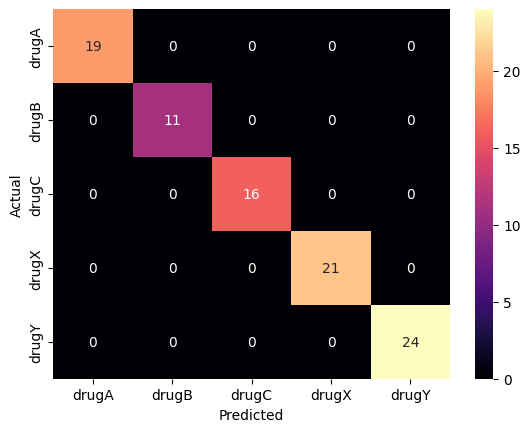

In [17]:
# model training
best_logistic = grid.best_estimator_
best_logistic.fit(x_train, y_train)
y_pred = best_logistic.predict(x_test)

print('Accuracy: ',accuracy_score(y_test, y_pred))
print('F1 macro score: ',f1_score(y_test, y_pred, average = 'macro'))
print('\n')
print(classification_report(y_test, y_pred))
print('\n')

# cofusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, cmap = 'magma', xticklabels=class_enc.classes_, yticklabels=class_enc.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [20]:
# features reduction
importance_df = pd.DataFrame({
    'feature': x.columns,
    'importance': abs(best_logistic.coef_[0])
})
importance_df

,feature,importance
0,Age,4.479089
1,Gender,0.000000
2,BloodPressure,12.131671
3,Cholestrol,2.007029
4,Na_to_K,5.021095


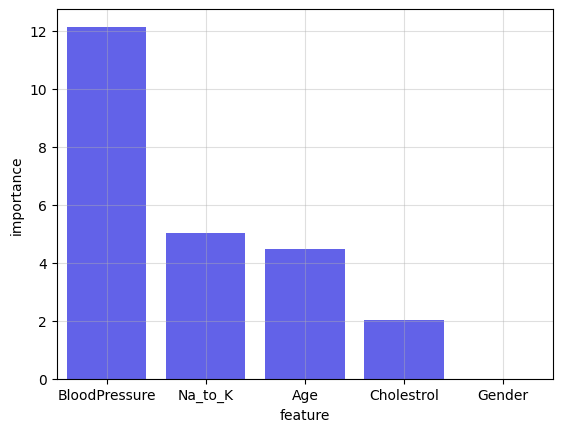

In [22]:
# bar plot
sns.barplot(
    data = importance_df.sort_values(by = 'importance', ascending = False),
    x = 'feature',
    y = 'importance',
    color = 'blue',
    alpha = 0.7
)
plt.grid(True, alpha = 0.4)
plt.show()

In [25]:
# Dimensionality reduction
# eliminating "Gender"
selected_features = importance_df[importance_df['importance'] > 0.01]['feature']
selected_features

,feature
0,Age
2,BloodPressure
3,Cholestrol
4,Na_to_K


In [26]:
x_reduced = df[selected_features]

In [27]:
# split
x_trainr, x_testr, y_trainr, y_testr = train_test_split(x_reduced,y,test_size = 0.2, random_state = 42)

In [28]:
# best model training on reduced data
best_model_reduced = LogisticRegression(**grid.best_params_)
best_model_reduced.fit(x_trainr, y_trainr)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(C=np.float64(10.0), l1_ratio=0.2, max_iter=1000,
                   penalty='l1', solver='saga')

In [30]:
y_Pred = best_model_reduced.predict(x_testr)
print('Accuracy: ',accuracy_score(y_testr, y_Pred))
print('F1 macro score: ',f1_score(y_testr, y_Pred, average = 'macro'))

Accuracy:  0.9340659340659341
F1 macro score:  0.9298924794359577


In [31]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x_pca, y, test_size=0.2, random_state=42)

sr = LogisticRegression(**grid.best_params_)
sr.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(C=np.float64(10.0), l1_ratio=0.2, max_iter=1000,
                   penalty='l1', solver='saga')

/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


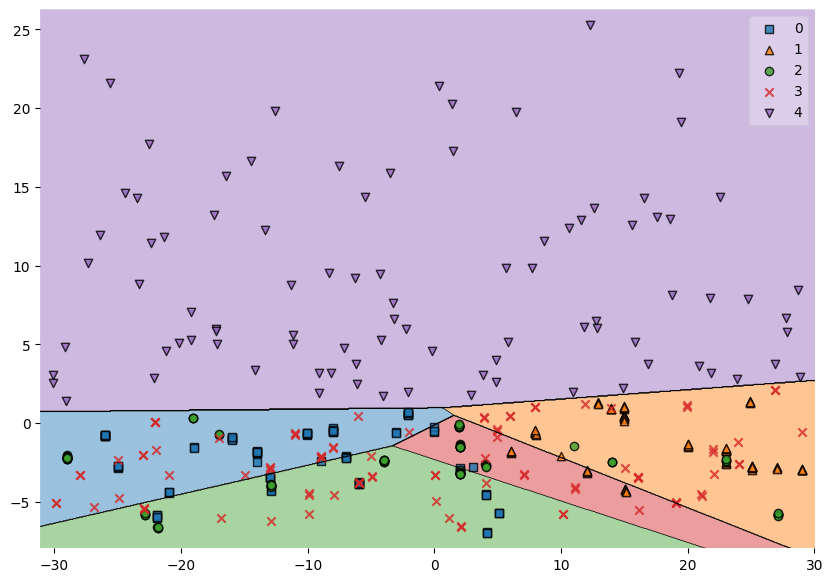

In [32]:
plt.figure(figsize=(10,7))
plot_decision_regions(x_pca, y.values, clf=sr, legend=1)
plt.show()